Fake News Detection with NLP and Transformers 
Explore how to detect fake news using News using Natural Language Processing (NLP) and Transformers like BERT.
Useful for social media, news platforms and fact-checking organizations to spot misleading information

In [2]:
#Suppress warnings to keep output clean 
import warnings 
import numpy as np
np.random.seed(42)
warnings.filterwarnings("ignore")

In [3]:
#Data setup (Fake News Dtatset)
import pandas as pd

url = "https://raw.githubusercontent.com/lutzhamel/fake-news/refs/heads/master/data/fake_or_real_news.csv"

df = pd.read_csv(url)

df.head()

,id,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [4]:
print(df.shape)

(6335, 4)


What does the data look like?
Each row is an online news rticle headline:
There is a label column showing if it is"Fake" or "Real"

In [5]:
#check for missing values 
print(df.isnull().sum())

id       0
title    0
text     0
label    0
dtype: int64


In [6]:
#clean up misssing or bad data (if any)
df = df.dropna()
print(df.shape)

(6335, 4)


In [7]:
#Look at the balance of real vs fake news
print(df['label'].value_counts())

label
REAL    3171
FAKE    3164
Name: count, dtype: int64


In [8]:
# Combine title and article text

df["combined_text"] = (
    df["title"].fillna("") + " " + df["text"].fillna("")
)

# Check the result
df[["title", "text", "combined_text", "label"]].head()

,title,text,combined_text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",You Can Smell Hillary’s Fear Daniel Greenfield...,FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,Watch The Exact Moment Paul Ryan Committed Pol...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,Kerry to go to Paris in gesture of sympathy U....,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",Bernie supporters on Twitter erupt in anger ag...,FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,The Battle of New York: Why This Primary Matte...,REAL


Pratice prompt
Reasons why fake news is a challenge for society
1.Misinformation could lead to death if one reads a fake weather report
2.Misinformation could lead to using fake or bad drugs if one reads an article caliming that drug is good

In [9]:
#Eplore an article headline 
print(df.iloc[0]['text'])

Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Islam. 
In the final stretch of the election, Hillary Rodham Clinton has gone to war with the FBI. 
The word “unprecedented” has been thrown around so often this election that it ought to be retired. But it’s still unprecedented for the nominee of a major political party to go war with the FBI. 
But that’s exactly what Hillary and her people have done. Coma patients just waking up now and watching an hour of CNN from their hospital beds would assume that FBI Director James Comey is Hillary’s opponent in this election. 
The FBI is under attack by everyone from Obama to CNN. Hillary’s people have circulated a letter attacking Comey. There are currently more media hit pieces lambasting him than targeting Trump. It wouldn’t be too surprising if the Clintons or their allies were to start running attack ads against the FBI. 
The FBI’s leadership is being warned that the entire left

In [10]:
print(df.iloc[79]['text'])

BREAKING : DOJ Says They Will “HELP” Review the 650K Emails BREAKING : DOJ Says They Will “HELP” Review the 650K Emails Breaking News By Amy Moreno October 31, 2016 
Oh great, now the biased DOJ is going to “help” the FBI go through the 650K emails because they want to “HURRY THROUGH” it? 
That’s unsettling and smells of more “rigged favors” from Loretta Lynch. 
On Friday the FBI announced they were reopening the email investigation into Hillary’s mishandling of classified information. 
In a statement, the FBI said that they discovered “new emails” pertinent to the earlier investigation on “several devices.” 
We now know there were 650K emails found on Huma and Anthony’s private computer. 
How do you feel about the DOJ “helping” sift through the emails? 
I say, HELL NO! BREAKING: Justice Dept. says it’ll dedicate all needed resources to quickly review emails in Clinton case – AP This is a movement – we are the political OUTSIDERS fighting against the FAILED GLOBAL ESTABLISHMENT! Join t

In [27]:
#convert lables to numbers: REAL-1, FAKE-0
df['label_num'] = df['label'].map({'REAL':1, 'FAKE':0})

In [30]:
#Split data into training and test sets
from sklearn.model_selection import train_test_split
X = df['combined_text']
y = df['label']
X_train,X_test,y_train,y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [31]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

X shape: (6335,)
y shape: (6335,)

Class distribution:
label
REAL    3171
FAKE    3164
Name: count, dtype: int64


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5068
Testing samples: 1267


What is NLP?
NLP stands for Natural Language Processing
It is a field of AI that helps computers understand and work with human language.

In [33]:
#Convert text to features with TF-IDF (gives more importance to unique words)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (5068, 50000)
Testing TF-IDF shape: (1267, 50000)


In [34]:
#Simple model:Logistic Regression(it learns patterns to seprate fake from real articules)
#More Iterations so it has more time to learn
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [35]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [38]:
#Test accuracy
X_test_tfidf = tfidf.transform(X_test)

score = model.score(X_test_tfidf, y_test)
print(f"Test accuracy: {score:.2f}")

ValueError: X has 50000 features, but LogisticRegression is expecting 61359 features as input.

In [16]:
#Test with an article headline, make fake news prediction from user input 
headline = input("Type a news headline to check: ")
features = tfidf.transform([headline])
pred = model.predict(features)[0]
if pred == 1:
    print("This is article looks REAL.")
else:
    print("This article looks FAKE.")


This article looks FAKE.


How do Transformers works?
Transformers are like BERT can understand language much more deeply than older models.
They read the whole sentence and capture the real meaning of words as they appear in context .
This is helpful in detecting sarcasm, lies and subtle tricks in fake news.

In [17]:

%pip install transformers
%pip install torch


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [18]:
%pip uninstall -y transformers
%pip install "transformers==4.57.3"

Found existing installation: transformers 4.57.3
Uninstalling transformers-4.57.3:
  Successfully uninstalled transformers-4.57.3
Note: you may need to restart the kernel to use updated packages.
  Using cached transformers-4.57.3-py3-none-any.whl.metadata (43 kB)
Using cached transformers-4.57.3-py3-none-any.whl (12.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [19]:
import transformers
import torch

print("Transformers:", transformers.__version__)
print("Torch:", torch.__version__)
print("Torch available:", transformers.is_torch_available())

Transformers: 4.57.3
Torch: 2.14.0+cpu
Torch available: True


In [20]:
import torch
from transformers import pipeline

print("Torch:", torch.__version__)

bert_clf = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

result = bert_clf("Breaking news: The moon goes into eclipse!")

print(result)

Torch: 2.14.0+cpu


Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9975743889808655}]


In [21]:
from transformers import pipeline
bert_clf = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

result = bert_clf("Breaking news: Volcanos ar harmful!")

print(result)

Device set to use cpu


[{'label': 'NEGATIVE', 'score': 0.9874352216720581}]


In [22]:
from transformers import pipeline

fake_news_clf = pipeline(
    "text-classification",
    model="Amirmerfan/distilbert-uncased-fake-news-detector"
)

result = fake_news_clf(
    "Breaking news:Volcanos are real."
)

print(result)

Device set to use cpu


[{'label': 'Fake', 'score': 0.9997517466545105}]


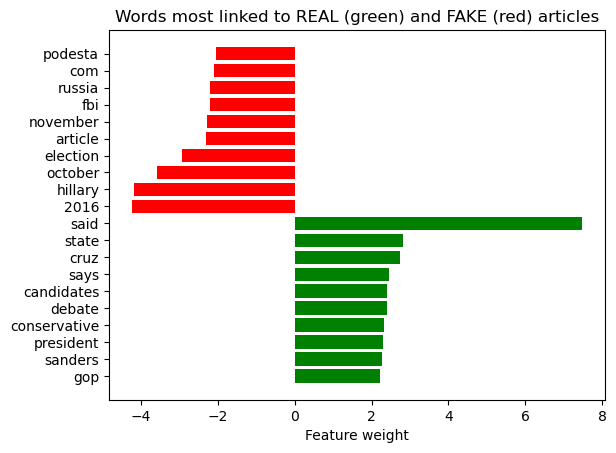

In [23]:
# Visualize word importance (feature weights)

import numpy as np
import matplotlib.pyplot as plt

# Get feature names from TF-IDF
feature_names = np.array(tfidf.get_feature_names_out())

# Get Logistic Regression coefficients
coefs = model.coef_[0]

top_features = 10

# Most strongly associated with the positive class
top_pos = np.argsort(coefs)[-top_features:]

# Most strongly associated with the negative class
top_neg = np.argsort(coefs)[:top_features]

# Plot
plt.barh(feature_names[top_pos], coefs[top_pos], color="green")
plt.barh(feature_names[top_neg], coefs[top_neg], color="red")

plt.xlabel("Feature weight")
plt.title("Words most linked to REAL (green) and FAKE (red) articles")

plt.show()

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Make predictions on the test set
y_pred = model.predict(x_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9155485398579322
Precision: 0.9332247557003257
Recall: 0.8967136150234741
F1 Score: 0.9146049481245012

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       628
           1       0.93      0.90      0.91       639

    accuracy                           0.92      1267
   macro avg       0.92      0.92      0.92      1267
weighted avg       0.92      0.92      0.92      1267



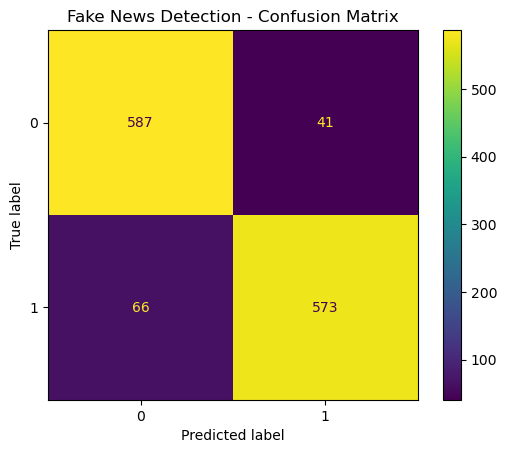

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Fake News Detection - Confusion Matrix")
plt.show()

In [26]:
print(model.classes_)
print(df["label"].value_counts())

[0 1]
label
REAL    3171
FAKE    3164
Name: count, dtype: int64


learnt to load and explore the Fake News datatset 
clean text data and encode labels 
Split data into training and test sets
turn headlines into features using aTF-IDF
train a logistic regression model 
Test the model and use it to predict new headlines 
Try BERT transformer for deeper understanding 
Visualize top words for fake vs real news 